**PRÁCTICA 3**

-Camila Montiel Zapata
-Luisa Fernanda Llamas

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

In [124]:
signal = sio.loadmat('signals (1).mat')
senales = signal['Fs']
print(f'Frecuencia de muestreo: {senales}')
senal_ = senales.flatten()
NC = len(senal_)
print(signal.keys())
print('el tamaño de la señal es:',senales.shape)

Frecuencia de muestreo: [[1024]]
dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
el tamaño de la señal es: (1, 1)


# **1.** Lectura de las señales 

In [125]:
#Señales ECG Y EMG CRUDAS
senalECG = signal['ECG_asRecording']
senal_fR = senalECG.flatten()
NC = len(senal_fR)

senalEMG1R = signal['EMG_asRecording1']
senal_fEMG = senalEMG1R.flatten()
NEMG = len(senal_fEMG)  

senalEMG2R = signal['EMG_asRecording2']
senal_EMG2 = senalEMG2R.flatten()  
NEMG2 = len(senal_EMG2)

#Señales ECG Y EMG FILTRADAS
senalECG_f = np.array(signal['ECG_filtered'])
senal_fECG = senalECG_f.flatten()


senalEMG1_f = signal['EMG_filtered1']
senal_fEMG1 = senalEMG1_f.flatten()
NEMG1 = len(senal_fEMG1)    

senal_fEMG2_f = signal['EMG_filtered2']
senal_fEMG2 = senal_fEMG2_f.flatten()       
NEMG2_f = len(senal_fEMG2)
print('la longitud de la señal es:', NEMG2_f) 

la longitud de la señal es: 30721


In [126]:
fs = 1024  # Frecuencia de muestreo (Hz)
t_f1 = np.arange(NC)/fs
t_f2 = np.arange(NEMG1)/fs
tiempo_1 = (0,t_f1+fs, fs)
tiempo_2 = (0,t_f2+fs, fs)

### **a)** Gráficas de las señales crudas y filtradas

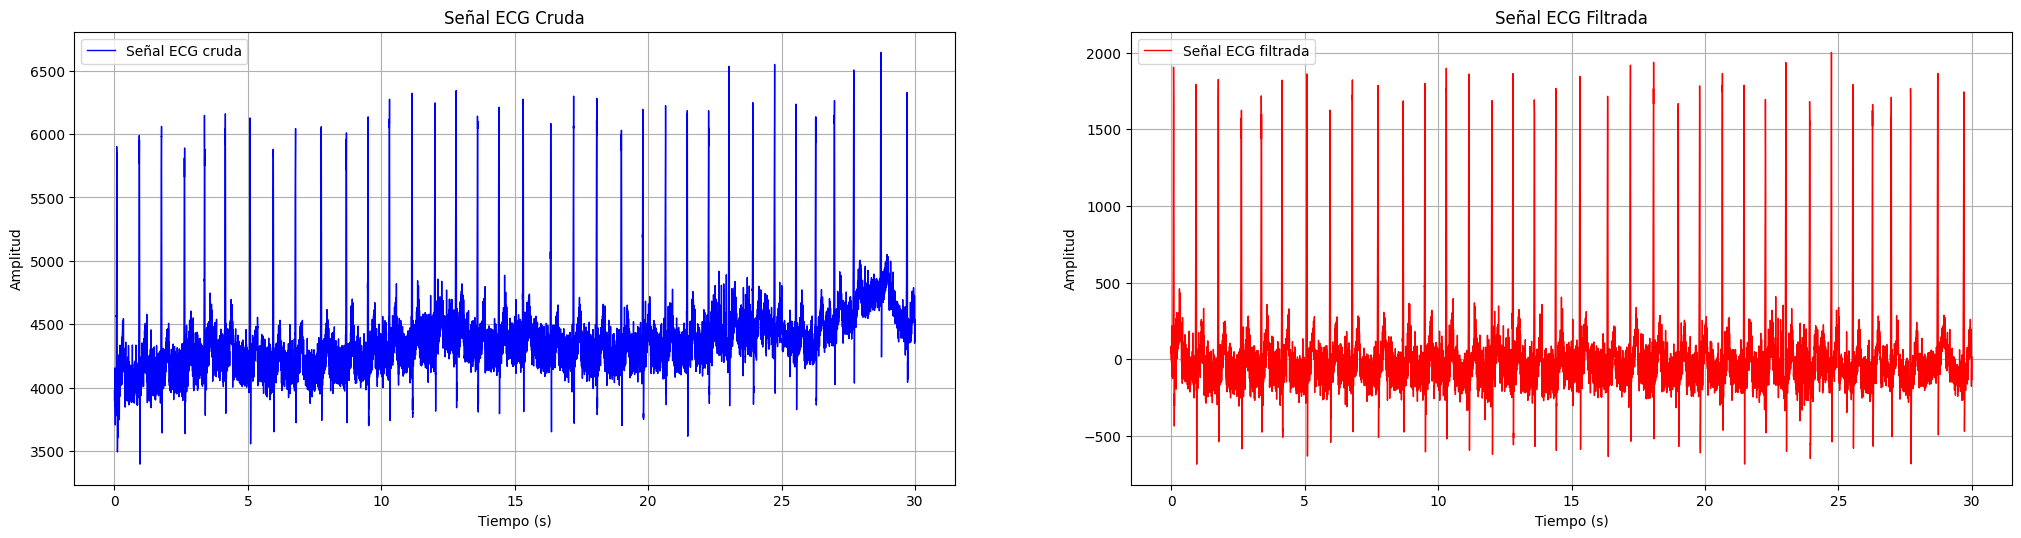

In [186]:
plt.figure(figsize=(25, 20))
plt.subplot(3, 2, 1)
plt.plot(t_f1, senal_fR, label='Señal ECG cruda', color='blue' , linewidth=1)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Cruda')
plt.legend()
plt.grid(True)
plt.subplot(3, 2, 2)
plt.plot(t_f1, senal_fECG, label='Señal ECG filtrada', color='red' , linewidth=1)   
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG Filtrada')
plt.legend()
plt.grid(True)


### **b)** Verificación de filtros

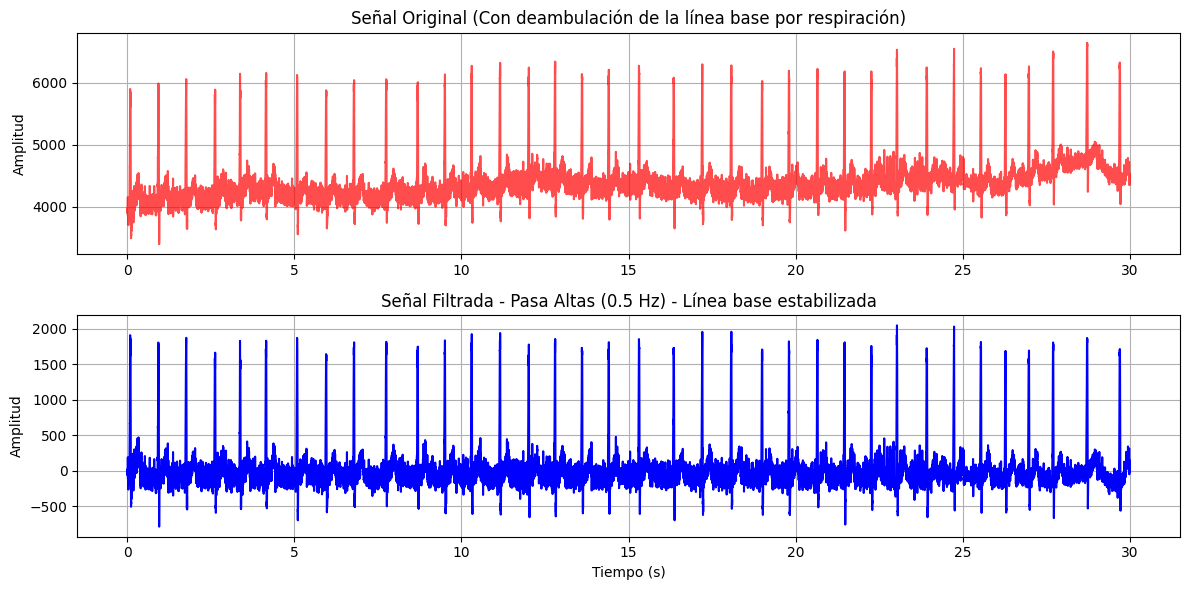

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# === 1. DEFINIR LA FUNCIÓN DEL FILTRO PASA ALTAS ===
def aplicar_pasa_altas(senal, fs, f_corte, orden=4):
    """
    Aplica un filtro pasa altas Butterworth a una señal.
    f_corte: Frecuencia por debajo de la cual se bloquea el ruido (ej. 0.5 Hz).
    """
    # 1. Diseñar el filtro pasa altas ('highpass')
    b, a = signal.butter(orden, f_corte, btype='highpass', fs=fs)
    
    # 2. Aplicar el filtro sin desfase temporal
    senal_limpia = signal.filtfilt(b, a, senal)
    
    return senal_limpia

# === 2. SIMULACIÓN DE DATOS  ===
fs = 1024  # Frecuencia de muestreo

senal_filtrada_pa = aplicar_pasa_altas(senal_fR, fs=fs, f_corte=0.5)

senal_detrend = signal.detrend(senal_filtrada_pa)
# === 4. GRAFICAR ===
plt.figure(figsize=(12, 6))

# Gráfica Original con oscilación lenta
plt.subplot(2, 1, 1)
plt.plot(t_f1, senal_fR, color='red', alpha=0.7)
plt.title('Señal Original (Con deambulación de la línea base por respiración)')
plt.ylabel('Amplitud')
plt.grid(True)

# Gráfica  Filtrada
plt.subplot(2, 1, 2)
plt.plot(t_f1, senal_detrend, color='blue')
plt.title('Señal Filtrada - Pasa Altas (0.5 Hz) - Línea base estabilizada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


En los graficos anteriores se aprecia lo siguiente: 


**a)** Al analizar las gráficas del ECG, se observa que la señal original (azul) presenta una ligera inclinación hacia el final del registro y resulta poco legible. Estas alteraciones suelen deberse a factores físicos, como el movimiento del tórax durante la respiración del paciente, lo que genera oscilaciones lentas que distorsionan el trazo. Como se evidencia en la señal resultante (roja), estos problemas se corrigen aplicando un proceso en dos partes. Primero, es necesario enderezar matemáticamente la gráfica para eliminar cualquier pendiente o desnivel, esta acción la cumple la función detrend. Posteriormente, se requiere implementar una barrera que bloquee esas ondas lentas causadas por la respiración, permitiendo que crucen únicamente las frecuencias rápidas de los latidos eléctricos cardíacos; este comportamiento es exactamente el que realiza un filtro pasa altas como se confirma en el item 1(b) de verificación de filtros.




### **2.** Parámetros Estadísticos del ECG: Señal Cruda vs. Filtrada

--- Estadísticos de la señal: Ciclo ECG Señal Cruda ---
Promedio:            4180.9677
Valor RMS:           146.4685
Varianza:            89522.2342
Desviación Estándar: 299.2027

--- Estadísticos de la señal: Ciclo ECG Señal Filtrada ---
Promedio:            -9.5482
Valor RMS:           10.3693
Varianza:            87970.0260
Desviación Estándar: 296.5974



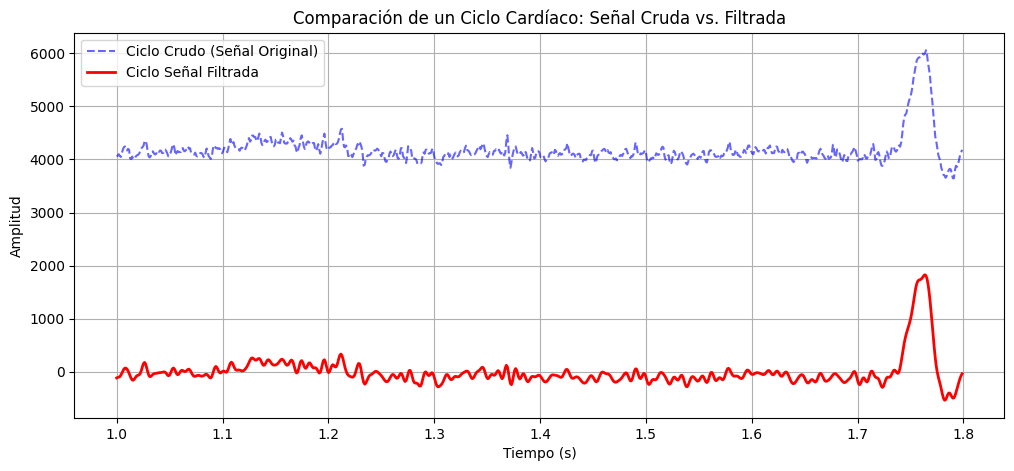

In [191]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. SELECCIONAR UN CICLO CARDÍACO ===


segundo_inicio = 1.0 
segundo_fin = 1.8    

inicio = int(segundo_inicio * fs)
fin = int(segundo_fin * fs)

# Recortamos el tiempo y las señales
t_ciclo = t_f2[inicio:fin]
ciclo_crudo = senal_fR[inicio:fin] 
ciclo_filtrado = senal_fECG[inicio:fin] 
NC = len(ciclo_crudo)  # Número de muestras en el ciclo
NF = len(ciclo_filtrado)  # Número de muestras en el ciclo filtrado
# === 2. FUNCIÓN PARA CÁLCULOS ESTADÍSTICOS ===
def calcular_estadisticos(ciclo, nombre_senal, N):
    promedio = np.mean(ciclo)

    def RMS_FUNC(N, ciclo):
        RMS_V = np.sqrt((1/N)*np.mean(ciclo**2))
        return RMS_V
    rms = RMS_FUNC(N, ciclo)
    varianza = np.var(ciclo)
    desviacion_est = np.std(ciclo)
    
    print(f"--- Estadísticos de la señal: {nombre_senal} ---")
    print(f"Promedio:            {promedio:.4f}")
    print(f"Valor RMS:           {rms:.4f}")
    print(f"Varianza:            {varianza:.4f}")
    print(f"Desviación Estándar: {desviacion_est:.4f}\n")
    
    return promedio, rms, varianza, desviacion_est

# === 3. IMPRIMIR RESULTADOS ===
stats_crudo = calcular_estadisticos(ciclo_crudo, "Ciclo ECG Señal Cruda", NC)
stats_filtrado = calcular_estadisticos(ciclo_filtrado, "Ciclo ECG Señal Filtrada", NF)

# === 4. GRAFICAR LA COMPARACIÓN ===
plt.figure(figsize=(12, 5))
plt.plot(t_ciclo, ciclo_crudo, label='Ciclo Crudo (Señal Original)', color='blue', alpha=0.6, linestyle='--')
plt.plot(t_ciclo, ciclo_filtrado, label='Ciclo Señal Filtrada', color='red', linewidth=2)
plt.title('Comparación de un Ciclo Cardíaco: Señal Cruda vs. Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

- flatantes extraer los 15 xixlo(graficar y analizar cada uno) y valor prmedio y variansa
- relaizar comparacion de ds ciclos de preba t (analizar si son iguales)......puebas
-comprobar la preuba dicki fuler (analisis)
-conclusion  

**Referencias**


1. Fig. 3 Different techniques for EMG signal processing. (n.d.). ResearchGate. https://www.researchgate.net/figure/Different-techniques-for-EMG-signal-processing_fig3_339515985

2. Kligfield, P., Gettes, L. S., Bailey, J. J., Childers, R., Deal, B. J., Hancock, E. W., Van Herpen, G., Kors, J. A., Macfarlane, P., Mirvis, D. M., Pahlm, O., Rautaharju, P., & Wagner, G. S. (2007). Recommendations for the standardization and interpretation of the electrocardiogram. Circulation, 115(10), 1306–1324. https://doi.org/10.1161/circulationaha.106.180200

